# Estimating Beta Using Regression in Python

*Quant Lab · The Analytical Investor · Year 1, Month 3*

**Read the article:** [Estimating Beta Using Regression in Python](https://analytical-investor.blog/?p=999)

We simulate a market and three stocks with **known** betas, estimate them by OLS, and see how wide the confidence intervals are, even with clean data.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Simulate five years of monthly returns, estimate each beta with its standard error and R², and measure how much a rolling 24-month estimate wanders.

In [2]:
import numpy as np

rng = np.random.default_rng(3)

# ------------------------------------------------------------------
# 1. Simulate 5 years of monthly returns with known betas
# ------------------------------------------------------------------
n = 60                                     # 60 months
rm = rng.normal(0.008, 0.045, n)           # market: ~10%/yr, ~16% vol

true = {"Utility": (0.5, 0.02), "Bank": (1.3, 0.04),
        "SmallCap": (1.8, 0.09)}           # (beta, idio vol)

stocks = {name: b * rm + rng.normal(0, s, n)
          for name, (b, s) in true.items()}

# ------------------------------------------------------------------
# 2. OLS beta by hand: cov/var identity, plus standard error
# ------------------------------------------------------------------
def ols_beta(r, m):
    mx, my = m.mean(), r.mean()
    beta = ((m - mx) * (r - my)).sum() / ((m - mx) ** 2).sum()
    alpha = my - beta * mx
    resid = r - alpha - beta * m
    se = np.sqrt((resid @ resid) / (len(r) - 2) / ((m - mx) ** 2).sum())
    r2 = 1 - (resid @ resid) / ((r - my) @ (r - my))
    return beta, alpha, se, r2

print(f"{'Stock':<9} {'true β':>6} {'est β':>6} {'SE':>5} "
      f"{'95% CI':>14} {'R²':>5}")
for name, r in stocks.items():
    b, a, se, r2 = ols_beta(r, rm)
    lo, hi = b - 1.96 * se, b + 1.96 * se
    print(f"{name:<9} {true[name][0]:>6.2f} {b:>6.2f} {se:>5.2f} "
      f"[{lo:>5.2f},{hi:>5.2f}] {r2:>5.2f}")

# ------------------------------------------------------------------
# 3. Instability: rolling 24-month beta for the bank
# ------------------------------------------------------------------
r = stocks["Bank"]
roll = [ols_beta(r[t-24:t], rm[t-24:t])[0] for t in range(24, n)]
print(f"\nBank rolling 24m beta: min {min(roll):.2f}, "
      f"max {max(roll):.2f} (true: 1.30)")

Stock     true β  est β    SE         95% CI    R²
Utility     0.50   0.43  0.06 [ 0.32, 0.55]  0.48
Bank        1.30   1.22  0.10 [ 1.02, 1.42]  0.71
SmallCap    1.80   1.91  0.22 [ 1.47, 2.35]  0.56

Bank rolling 24m beta: min 1.11, max 1.40 (true: 1.30)


### The picture
Left: the bank's returns against the market with the fitted line. Right: the rolling 24-month beta drifting around a true value that never changes.

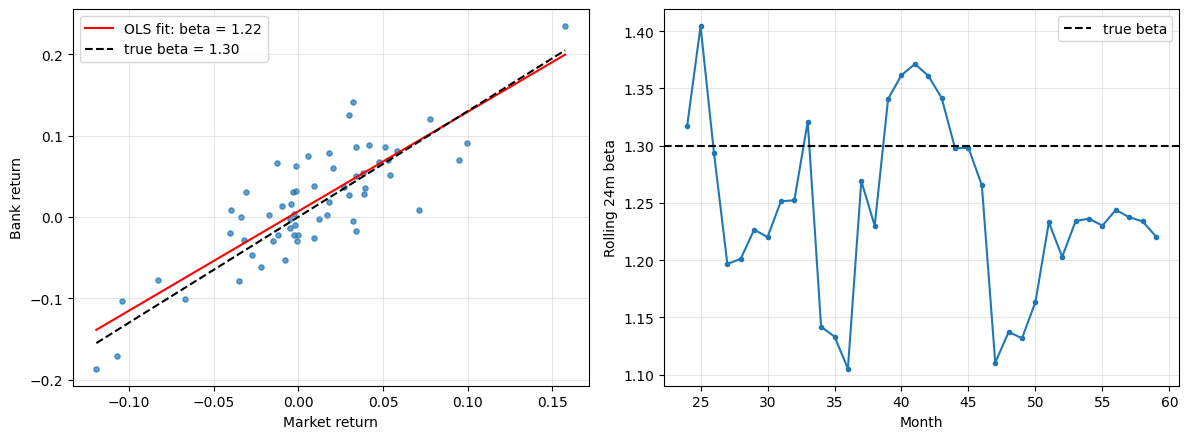

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
b, a, se, r2 = ols_beta(stocks["Bank"], rm)
a1.scatter(rm, stocks["Bank"], s=14, alpha=0.7)
xs = np.linspace(rm.min(), rm.max(), 50)
a1.plot(xs, a + b * xs, "r-", label=f"OLS fit: beta = {b:.2f}")
a1.plot(xs, 1.3 * xs, "k--", label="true beta = 1.30")
a1.set_xlabel("Market return"); a1.set_ylabel("Bank return"); a1.legend()
a2.plot(range(24, n), roll, marker="o", ms=3)
a2.axhline(1.3, color="k", ls="--", label="true beta")
a2.set_xlabel("Month"); a2.set_ylabel("Rolling 24m beta"); a2.legend()
plt.tight_layout(); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [4]:
from analytical_investor import regression

res = regression.ols_beta(stocks["Bank"], rm)
print(f"beta {res.beta:.2f}, 95% CI {res.ci()[0]:.2f} to {res.ci()[1]:.2f}, R² {res.r2:.2f}")
print(f"Blume-adjusted beta: {regression.blume_adjusted(res.beta):.2f}")

beta 1.22, 95% CI 1.02 to 1.42, R² 0.71
Blume-adjusted beta: 1.15


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=999).